# 遮蔽率 × GPS誤差 グラフ作成 Notebook

`analysis_pipeline.py` で出力した `occlusion_rate.csv` / `correlation.csv` を読んで、論文用のグラフ3枚を作成します。

各セルを独立して実行・調整できます。**ラベル・色・サイズなどはセル内の変数を変えてShift+Enterで即確認できます。**

## 構成
- セル1: ライブラリ import・共通スタイル設定
- セル2: CSV読み込み
- セル3: **Fig.1** 遮蔽率時系列（横軸: フレームindex, 縦軸: 遮蔽率）
- セル4: **Fig.2** GPS誤差時系列（横軸: フレームindex, 縦軸: GPS-GLIM誤差, 背景: 遮蔽率）
- セル5: **Fig.3** 相関散布図（横軸: 遮蔽率, 縦軸: GPS誤差）
- セル6: 全グラフをPNG保存（パワポ用）


## セル1: ライブラリ import・共通スタイル設定

論文向けの白背景・serif フォント・グリッド表示などを共通設定。  
**ここを変えると全グラフに反映されます。**


In [1]:
import sys
# システム版の古いmatplotlibを除外して pip版を優先する
sys.path = [p for p in sys.path if '/usr/lib/python3/dist-packages' not in p]

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

try:
    from scipy import stats as sp_stats
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False
    print("[WARN] scipy が無いため Pearson/Spearman は計算できません")

# ──────────────────────────────────────────────
#  共通スタイル（論文向け）
# ──────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size":          11,
    "axes.titlesize":     12,
    "axes.labelsize":     11,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    9,
    "legend.framealpha":  0.85,
    "lines.linewidth":    1.2,
    "axes.linewidth":     0.8,
    "grid.linewidth":     0.5,
    "grid.color":         "#cccccc",
    "grid.linestyle":     "--",
    "figure.dpi":         100,            # 画面表示用
    "savefig.dpi":        300,            # PNG保存用（論文品質）
    "savefig.bbox":       "tight",
    "savefig.facecolor":  "white",
    "axes.facecolor":     "white",
    "figure.facecolor":   "white",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

print("matplotlib スタイル設定 完了")

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


matplotlib スタイル設定 完了


## セル2: CSV読み込み

`analysis_pipeline.py` の出力ディレクトリを指定してCSVを読み込みます。


In [4]:
# ──────────────────────────────────────────────
#  ここを編集: CSVのある出力ディレクトリ
# ──────────────────────────────────────────────
OUT_DIR = os.path.expanduser("~/ros2_ws/dump/slope_0522/analysis/")

occ_df  = pd.read_csv(os.path.join(OUT_DIR, "occlusion_rate.csv"))
print(f"occlusion_rate.csv: {len(occ_df)} 行")
print(occ_df.head())

corr_csv = os.path.join(OUT_DIR, "correlation.csv")
if os.path.exists(corr_csv):
    corr_df = pd.read_csv(corr_csv)
    print(f"\ncorrelation.csv: {len(corr_df)} 行")
    print(corr_df.head())
else:
    corr_df = None
    print("\n[INFO] correlation.csv が無いため Fig.2, Fig.3 はスキップしてください")

occlusion_rate.csv: 63 行
          stamp  occlusion_rate  folder  n_upper  n_in_range
0  1.779445e+09           0.339       0    27491       11979
1  1.779445e+09           0.336       1    23594        9539
2  1.779445e+09           0.341       2    22620        8720
3  1.779445e+09           0.336       3    20298        7575
4  1.779445e+09           0.317       4    20111        6776

correlation.csv: 63 行
          stamp  occlusion_rate  gps_error    x_glim     y_glim     x_gps  \
0  1.779445e+09           0.339   0.012425  3.503751 -26.897719  3.492845   
1  1.779445e+09           0.336   0.659930  3.824752 -29.686110  3.268395   
2  1.779445e+09           0.341   1.334602  4.009327 -31.472210  2.674941   
3  1.779445e+09           0.336   1.091212  4.168615 -33.185742  3.429154   
4  1.779445e+09           0.317   0.657467  4.264610 -34.460684  3.691578   

       y_gps  
0 -26.903671  
1 -30.041039  
2 -31.448233  
3 -33.988201  
4 -34.783013  


## セル3: Fig.1 — 遮蔽率時系列

横軸: フレームindex（1, 2, 3, ...）  
縦軸: 遮蔽率 [0–1]

生データと移動平均を重ねて表示します。**`CFG` 辞書のパラメータを変えて即調整できます。**


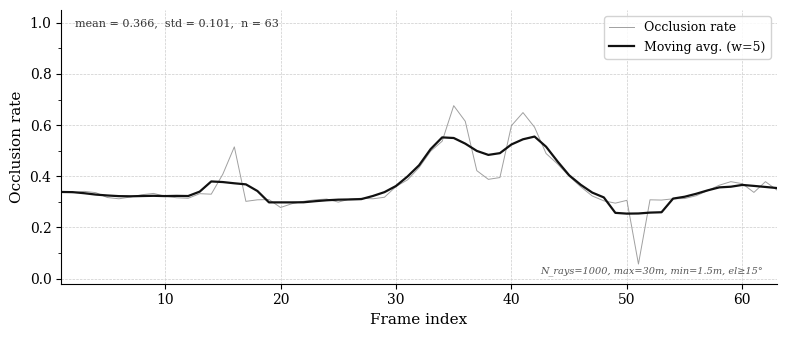

In [5]:
# ──────────────────────────────────────────────
#  Fig.1 設定（ここを編集して再実行）
# ──────────────────────────────────────────────
CFG = {
    "fig_size":       (8.0, 3.5),    # 図サイズ [inch]
    "raw_color":      "#888888",     # 生データの線色
    "raw_lw":         0.7,           # 生データの線幅
    "ma_color":       "#111111",     # 移動平均の線色
    "ma_lw":          1.6,           # 移動平均の線幅
    "ma_window":      5,             # 移動平均の窓幅（奇数推奨）
    "xlabel":         "Frame index",
    "ylabel":         "Occlusion rate",
    "ylim":           (-0.02, 1.05),
    "show_stats":     True,          # 左上に統計値を表示
    "show_params":    True,          # 右下にパラメータ条件を表示
}

# ──────────────────────────────────────────────
#  描画
# ──────────────────────────────────────────────
occ  = occ_df["occlusion_rate"].values
idx  = np.arange(1, len(occ) + 1)

# 移動平均
w      = min(CFG["ma_window"], len(occ))
kernel = np.ones(w) / w
ma     = np.convolve(occ, kernel, mode='same')
norm   = np.convolve(np.ones_like(occ), kernel, mode='same')
ma    /= norm

fig, ax = plt.subplots(figsize=CFG["fig_size"])
ax.plot(idx, occ, color=CFG["raw_color"], lw=CFG["raw_lw"], alpha=0.8,
        label="Occlusion rate")
ax.plot(idx, ma, color=CFG["ma_color"], lw=CFG["ma_lw"],
        label=f"Moving avg. (w={w})")

ax.set_xlabel(CFG["xlabel"])
ax.set_ylabel(CFG["ylabel"])
ax.set_xlim(idx[0], idx[-1])
ax.set_ylim(*CFG["ylim"])
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.grid(True)
ax.legend(loc="upper right")

if CFG["show_stats"]:
    ax.text(0.02, 0.97,
            f"mean = {occ.mean():.3f},  std = {occ.std():.3f},  n = {len(occ)}",
            transform=ax.transAxes, fontsize=8, va="top", color="#333333")

if CFG["show_params"]:
    ax.text(0.98, 0.03,
            "N_rays=1000, max=30m, min=1.5m, el≥15°",
            transform=ax.transAxes, fontsize=7, va="bottom", ha="right",
            color="#555555", style="italic")

fig.tight_layout()
plt.show()

## セル4: Fig.2 — GPS-GLIM 誤差時系列

横軸: フレームindex（相関テーブルの順序）  
左Y軸: GPS-GLIM 誤差 [m]  
右Y軸 / 背景塗り: 遮蔽率

遮蔽が高い区間で誤差も大きいかを1枚で視覚確認できます。


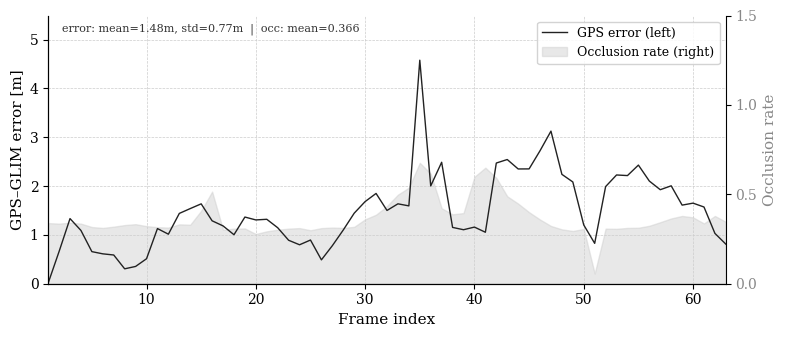

In [6]:
# ──────────────────────────────────────────────
#  Fig.2 設定
# ──────────────────────────────────────────────
CFG = {
    "fig_size":       (8.0, 3.5),
    "err_color":      "#222222",     # GPS誤差の線色
    "err_lw":         1.0,           # GPS誤差の線幅
    "occ_fill_color": "#cccccc",     # 遮蔽率塗り色
    "occ_fill_alpha": 0.45,          # 遮蔽率塗りの透明度
    "xlabel":         "Frame index",
    "ylabel_left":    "GPS–GLIM error [m]",
    "ylabel_right":   "Occlusion rate",
    "ylim_right":     (0, 1.5),      # 右軸は塗りが上に伸びすぎないよう余白
    "show_stats":     True,
}

# ──────────────────────────────────────────────
#  描画
# ──────────────────────────────────────────────
assert corr_df is not None, "correlation.csv が無いため Fig.2 は生成できません"

idx = np.arange(1, len(corr_df) + 1)
err = corr_df["gps_error"].values
occ = corr_df["occlusion_rate"].values

fig, ax1 = plt.subplots(figsize=CFG["fig_size"])
ax2 = ax1.twinx()

# 背景: 遮蔽率の塗り
ax2.fill_between(idx, 0, occ, color=CFG["occ_fill_color"],
                 alpha=CFG["occ_fill_alpha"],
                 label="Occlusion rate (right)")
ax2.set_ylabel(CFG["ylabel_right"], color="#888888")
ax2.tick_params(axis="y", labelcolor="#888888")
ax2.set_ylim(*CFG["ylim_right"])
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_linewidth(0.8)
ax2.spines["top"].set_visible(False)
ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.5))

# 前面: GPS誤差
ax1.plot(idx, err, color=CFG["err_color"], lw=CFG["err_lw"],
         label="GPS error (left)")
ax1.set_xlabel(CFG["xlabel"])
ax1.set_ylabel(CFG["ylabel_left"])
ax1.set_xlim(idx[0], idx[-1])
ax1.set_ylim(0, err.max() * 1.2)
ax1.grid(True)
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# 凡例統合
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=9)

if CFG["show_stats"]:
    ax1.text(0.02, 0.97,
             f"error: mean={err.mean():.2f}m, std={err.std():.2f}m  |  "
             f"occ: mean={occ.mean():.3f}",
             transform=ax1.transAxes, fontsize=8, va="top", color="#333333")

fig.tight_layout()
plt.show()

## セル5: Fig.3 — 相関散布図

横軸: 遮蔽率  
縦軸: GPS誤差 [m]

+ 最小二乗回帰直線
+ Pearson r / Spearman ρ / p値


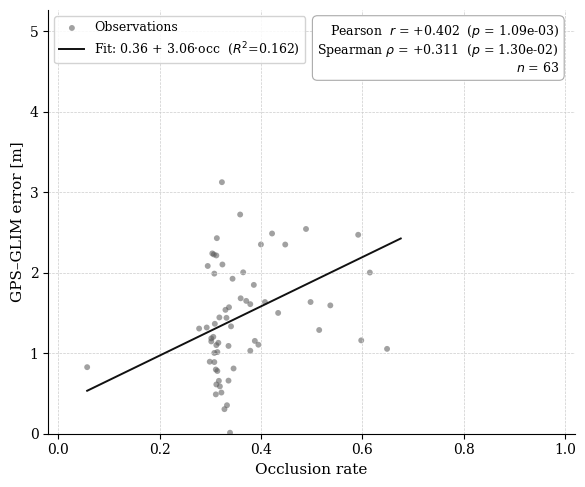

Pearson  r = +0.4021  (p = 1.088e-03)
Spearman ρ = +0.3114  (p = 1.298e-02)
回帰直線: err = 0.360 + 3.058 * occ  (R² = 0.1617)


In [7]:
# ──────────────────────────────────────────────
#  Fig.3 設定
# ──────────────────────────────────────────────
CFG = {
    "fig_size":       (6.0, 5.0),
    "scatter_color":  "#555555",
    "scatter_size":   18,
    "scatter_alpha":  0.55,
    "fit_color":      "#111111",
    "fit_lw":         1.4,
    "xlabel":         "Occlusion rate",
    "ylabel":         "GPS–GLIM error [m]",
    "xlim":           (-0.02, 1.02),
    "show_stats_box": True,
}

# ──────────────────────────────────────────────
#  描画
# ──────────────────────────────────────────────
assert corr_df is not None, "correlation.csv が無いため Fig.3 は生成できません"

occ = corr_df["occlusion_rate"].values
err = corr_df["gps_error"].values

# 相関係数
if HAS_SCIPY:
    pr,  pp  = sp_stats.pearsonr(occ, err)
    spr, spp = sp_stats.spearmanr(occ, err)
else:
    pr = pp = spr = spp = float("nan")

# 最小二乗回帰
A = np.vstack([np.ones_like(occ), occ]).T
coef, *_ = np.linalg.lstsq(A, err, rcond=None)
a, b = coef[0], coef[1]
xs = np.linspace(occ.min(), occ.max(), 200)
ys = a + b * xs
pred = A @ coef
ss_r = np.sum((err - pred) ** 2)
ss_t = np.sum((err - err.mean()) ** 2)
r2 = 1 - ss_r / ss_t if ss_t > 0 else float("nan")

fig, ax = plt.subplots(figsize=CFG["fig_size"])
ax.scatter(occ, err, color=CFG["scatter_color"], s=CFG["scatter_size"],
           alpha=CFG["scatter_alpha"], edgecolors="none", label="Observations")
ax.plot(xs, ys, color=CFG["fit_color"], lw=CFG["fit_lw"],
        label=f"Fit: {a:.2f} + {b:.2f}·occ  ($R^2$={r2:.3f})")

ax.set_xlabel(CFG["xlabel"])
ax.set_ylabel(CFG["ylabel"])
ax.set_xlim(*CFG["xlim"])
ax.set_ylim(0, max(err.max() * 1.15, 1.0))
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.grid(True)

if CFG["show_stats_box"] and HAS_SCIPY:
    txt = (f"Pearson  $r$ = {pr:+.3f}  ($p$ = {pp:.2e})\n"
           f"Spearman $\\rho$ = {spr:+.3f}  ($p$ = {spp:.2e})\n"
           f"$n$ = {len(occ)}")
    ax.text(0.97, 0.97, txt, transform=ax.transAxes,
            fontsize=9, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="#aaaaaa", linewidth=0.8))

ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

# 統計をコンソールにも表示
if HAS_SCIPY:
    print(f"Pearson  r = {pr:+.4f}  (p = {pp:.3e})")
    print(f"Spearman ρ = {spr:+.4f}  (p = {spp:.3e})")
print(f"回帰直線: err = {a:.3f} + {b:.3f} * occ  (R² = {r2:.4f})")

## セル6: 全グラフをPNG保存（パワポ・論文用）

満足のいくグラフが完成したら、このセルでまとめてPNG保存します。  
**`savefig.dpi=300`** で論文品質。

セル3〜5を直前に実行してから、このセルを実行してください。


In [8]:
# ──────────────────────────────────────────────
#  保存先（OUT_DIRと同じディレクトリに保存）
# ──────────────────────────────────────────────
SAVE_DIR = OUT_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

# 直前に作成したFigureがそれぞれ生きている前提で、
# ここでは「セル3-5を保存付きで再実行する」やり方を取る。
# 各セル末尾の plt.show() を fig.savefig(...) に書き換えれば直接保存も可能。

# ── Fig.1 再生成 + 保存 ─────────────────────
occ_all = occ_df["occlusion_rate"].values
idx_all = np.arange(1, len(occ_all) + 1)
w       = 5
kernel  = np.ones(w) / w
ma_all  = np.convolve(occ_all, kernel, mode='same') / \
          np.convolve(np.ones_like(occ_all), kernel, mode='same')

fig, ax = plt.subplots(figsize=(8.0, 3.5))
ax.plot(idx_all, occ_all, color="#888888", lw=0.7, alpha=0.8, label="Occlusion rate")
ax.plot(idx_all, ma_all,  color="#111111", lw=1.6, label=f"Moving avg. (w={w})")
ax.set_xlabel("Frame index"); ax.set_ylabel("Occlusion rate")
ax.set_xlim(idx_all[0], idx_all[-1]); ax.set_ylim(-0.02, 1.05)
ax.grid(True); ax.legend(loc="upper right")
fig.tight_layout()
p1 = os.path.join(SAVE_DIR, "fig1_occlusion_series.png")
fig.savefig(p1); plt.close(fig)
print(f"保存: {p1}")

# ── Fig.2 & Fig.3 は correlation.csv が必要 ──
if corr_df is not None:
    idx = np.arange(1, len(corr_df) + 1)
    err = corr_df["gps_error"].values
    occ = corr_df["occlusion_rate"].values

    # Fig.2
    fig, ax1 = plt.subplots(figsize=(8.0, 3.5))
    ax2 = ax1.twinx()
    ax2.fill_between(idx, 0, occ, color="#cccccc", alpha=0.45, label="Occlusion rate (right)")
    ax2.set_ylabel("Occlusion rate", color="#888888")
    ax2.tick_params(axis="y", labelcolor="#888888"); ax2.set_ylim(0, 1.5)
    ax2.spines["right"].set_visible(True); ax2.spines["top"].set_visible(False)
    ax1.plot(idx, err, color="#222222", lw=1.0, label="GPS error (left)")
    ax1.set_xlabel("Frame index"); ax1.set_ylabel("GPS–GLIM error [m]")
    ax1.set_xlim(idx[0], idx[-1]); ax1.set_ylim(0, err.max() * 1.2)
    ax1.grid(True); ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper right")
    fig.tight_layout()
    p2 = os.path.join(SAVE_DIR, "fig2_gps_error_series.png")
    fig.savefig(p2); plt.close(fig)
    print(f"保存: {p2}")

    # Fig.3
    if HAS_SCIPY:
        pr,  pp  = sp_stats.pearsonr(occ, err)
        spr, spp = sp_stats.spearmanr(occ, err)
    A = np.vstack([np.ones_like(occ), occ]).T
    coef, *_ = np.linalg.lstsq(A, err, rcond=None)
    a, b = coef[0], coef[1]
    xs = np.linspace(occ.min(), occ.max(), 200); ys = a + b * xs
    pred = A @ coef
    r2 = 1 - np.sum((err - pred) ** 2) / np.sum((err - err.mean()) ** 2)

    fig, ax = plt.subplots(figsize=(6.0, 5.0))
    ax.scatter(occ, err, color="#555555", s=18, alpha=0.55, edgecolors="none",
               label="Observations")
    ax.plot(xs, ys, color="#111111", lw=1.4,
            label=f"Fit: {a:.2f} + {b:.2f}·occ  ($R^2$={r2:.3f})")
    ax.set_xlabel("Occlusion rate"); ax.set_ylabel("GPS–GLIM error [m]")
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(0, max(err.max() * 1.15, 1.0))
    ax.grid(True)
    if HAS_SCIPY:
        txt = (f"Pearson  $r$ = {pr:+.3f}  ($p$ = {pp:.2e})\n"
               f"Spearman $\\rho$ = {spr:+.3f}  ($p$ = {spp:.2e})\n"
               f"$n$ = {len(occ)}")
        ax.text(0.97, 0.97, txt, transform=ax.transAxes,
                fontsize=9, va="top", ha="right",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                          edgecolor="#aaaaaa", linewidth=0.8))
    ax.legend(loc="upper left")
    fig.tight_layout()
    p3 = os.path.join(SAVE_DIR, "fig3_correlation.png")
    fig.savefig(p3); plt.close(fig)
    print(f"保存: {p3}")

print("\n全保存完了。300dpi PNG なので論文・パワポにそのまま貼れます。")

保存: /home/ubuntu/ros2_ws/dump/slope_0522/analysis/fig1_occlusion_series.png
保存: /home/ubuntu/ros2_ws/dump/slope_0522/analysis/fig2_gps_error_series.png
保存: /home/ubuntu/ros2_ws/dump/slope_0522/analysis/fig3_correlation.png

全保存完了。300dpi PNG なので論文・パワポにそのまま貼れます。
